In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
listings = pd.read_csv(
    "../Data/cleaned/Listings_Clean.csv",
    parse_dates=["host_since"]
)
reviews = pd.read_csv(
    "../Data/cleaned/Reviews_Clean.csv"
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_18908\2675637001.py:1: DtypeWarning: Columns (5,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv(


In [3]:
listings_eda = listings.copy()
reviews_eda = reviews.copy()

Business Question 1
How are Airbnb listings distributed across different cities?

Objective:
Understand the distribution of Airbnb listings across the cities in the dataset and identify the largest and smallest markets.

In [4]:
city_counts=listings_eda["city"].value_counts().reset_index()
city_counts.columns=["City","Number of listings"]

In [5]:
city_counts

,City,Number of listings
0,Paris,64628
1,New York,36984
2,Sydney,33630
3,Rome,27641
4,Rio de Janeiro,26608
5,Istanbul,24517
6,Mexico City,20058
7,Bangkok,19360
8,Cape Town,19086
9,Hong Kong,7087


In [6]:
city_counts.columns

Index(['City', 'Number of listings'], dtype='object')

In [7]:
city_counts.head()

,City,Number of listings
0,Paris,64628
1,New York,36984
2,Sydney,33630
3,Rome,27641
4,Rio de Janeiro,26608


In [8]:
city_counts.columns

Index(['City', 'Number of listings'], dtype='object')

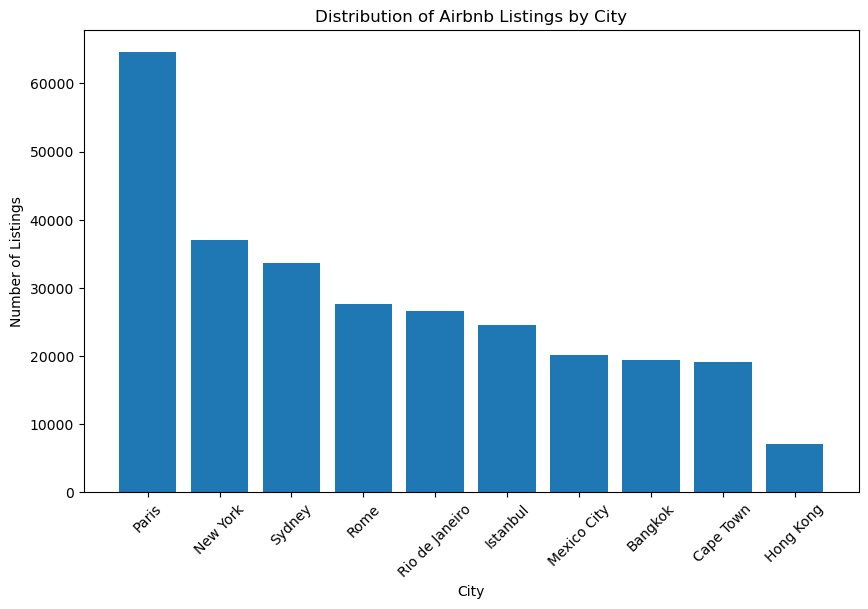

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(city_counts["City"], city_counts["Number of listings"])

plt.title("Distribution of Airbnb Listings by City")
plt.xlabel("City")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)
plt.show()


## Observations

- Paris has the highest number of Airbnb listings.
- Hong Kong has the fewest listings.
- While Paris has the largest market, listings are reasonably distributed across all ten cities rather than being concentrated in only one or two.

## Business Insight

Paris represents the largest and most competitive Airbnb market in the dataset. Since cities have different market sizes, comparing total counts in future analyses may be misleading.

## Recommendation

For future analyses, compare cities using average metrics (e.g., average rating, average price) rather than total values to ensure fair comparisons across markets.

Business Question 2
What are the most common property types on Airbnb?

Objective:
Identify the property types that dominate the Airbnb marketplace.

In [10]:
property_counts = (
    listings_eda["property_type"]
    .value_counts()
    .rename_axis("Property Type")
    .reset_index(name="Number of Listings")
)

property_counts.head(20)

,Property Type,Number of Listings
0,Entire apartment,138989
1,Private room in apartment,47322
2,Private room in house,13292
3,Entire house,13273
4,Entire condominium,11250
5,Room in boutique hotel,5705
6,Entire loft,4587
7,Private room in condominium,4462
8,Private room in bed and breakfast,4238
9,Entire serviced apartment,3973


In [11]:
top15_property=property_counts.head(15)


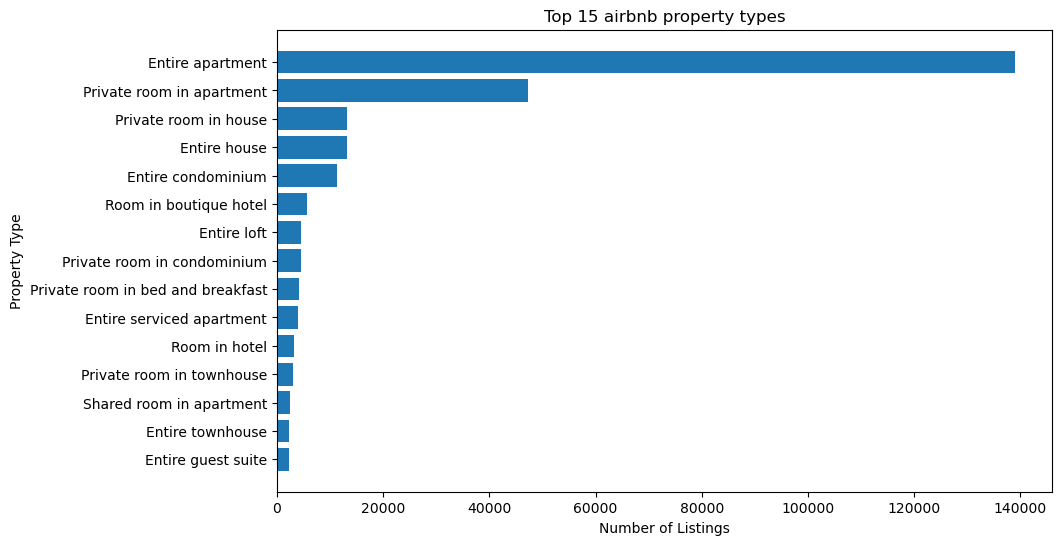

In [12]:
plt.figure(figsize=(10,6))
plt.barh(
    top15_property['Property Type'],
    top15_property['Number of Listings']
)
plt.title("Top 15 airbnb property types")
plt.xlabel('Number of Listings')
plt.ylabel('Property Type')
plt.gca().invert_yaxis()

plt.show()


## Observations

- Entire apartments are by far the most common property type on Airbnb.
- Private rooms in apartments are the second most common property type, but they are significantly fewer than entire apartments.
- The marketplace is concentrated around a small number of property types, with the remaining categories contributing relatively few listings.

## Business Insight

The Airbnb marketplace is dominated by entire apartments, indicating that guests are more commonly offered complete private accommodations than shared living spaces. This suggests that privacy and exclusive access are major characteristics of the marketplace.

## Recommendation

Future analyses should compare customer ratings, pricing, and booking characteristics across the major property types. Since entire apartments dominate the market, they should be analyzed separately from less common property types to identify factors that drive their performance.

In [13]:
listings_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279599 non-null  int64         
 1   name                         279424 non-null  object        
 2   host_id                      279599 non-null  int64         
 3   host_since                   279434 non-null  datetime64[ns]
 4   host_location                278759 non-null  object        
 5   host_response_time           150898 non-null  object        
 6   host_response_rate           150898 non-null  float64       
 7   host_acceptance_rate         166577 non-null  float64       
 8   host_is_superhost            279434 non-null  object        
 9   host_total_listings_count    279434 non-null  float64       
 10  host_has_profile_pic         279434 non-null  object        
 11  host_identity_verified    

Business Question 3
What room types are most commonly offered on Airbnb?

Objective:
Analyze the distribution of room types to understand the kinds of accommodations hosts primarily offer.

In [14]:
room_counts = listings_eda["room_type"].value_counts().reset_index()

room_counts.columns = ["Room Type", "Number of Listings"]
room_counts

,Room Type,Number of Listings
0,Entire place,182005
1,Private room,86988
2,Hotel room,5744
3,Shared room,4862


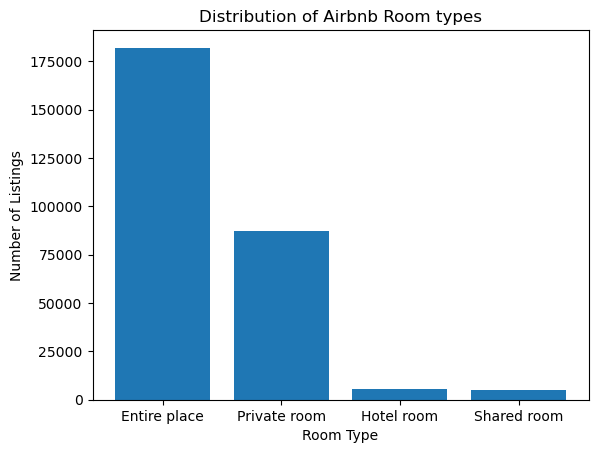

In [15]:
plt.Figure(figsize=(8,5))
plt.bar(
  room_counts['Room Type'],room_counts['Number of Listings']
)
plt.title('Distribution of Airbnb Room types')
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

## Observations

- Entire places account for the majority of Airbnb listings.
- Private rooms are the second most common option but are less than half as common as entire places.
- Hotel rooms and shared rooms represent only a small portion of the marketplace.

## Business Insight

The Airbnb marketplace is primarily built around offering guests private accommodations rather than shared spaces. This indicates that privacy is a major feature of the platform and may influence guest satisfaction and pricing.

## Recommendation

Future analyses should investigate whether room type affects guest ratings, pricing, and customer satisfaction. Since entire places dominate the marketplace, they should be analyzed separately from private and shared accommodations.

In [16]:
listings_eda['price'].describe()

count    279599.000000
mean        609.038781
std        3442.500286
min           1.000000
25%          75.000000
50%         150.000000
75%         475.000000
max      625216.000000
Name: price, dtype: float64

Business Question 4
How are Airbnb listing prices distributed?

Objective:
Understand the overall pricing distribution, identify outliers, and determine the typical price range of listings.

In [17]:
listings_eda[
    ["listing_id", "city", "property_type", "room_type", "price"]
].sort_values("price", ascending=False).head(10)

,listing_id,city,property_type,room_type,price
181026,13879989,Rio de Janeiro,Shared room in house,Shared room,625216
162250,47885441,Mexico City,Room in boutique hotel,Private room,499000
98807,23895520,Mexico City,Private room in house,Private room,350000
135704,3410763,Bangkok,Private room in apartment,Private room,300177
218484,12056763,Bangkok,Entire house,Entire place,300000
182184,13033135,Bangkok,Private room in house,Private room,300000
44906,29970931,Bangkok,Entire apartment,Entire place,231047
196423,38733276,Mexico City,Private room in apartment,Private room,206499
97609,41578696,Bangkok,Entire villa,Entire place,180124
212753,36421447,Cape Town,Entire villa,Entire place,180000


In [18]:
(listings_eda["price"] > 5000).sum()

np.int64(3778)

In [19]:
(
    (listings_eda["price"] > 5000).sum() /
    len(listings_eda)
) * 100

np.float64(1.3512208555824592)

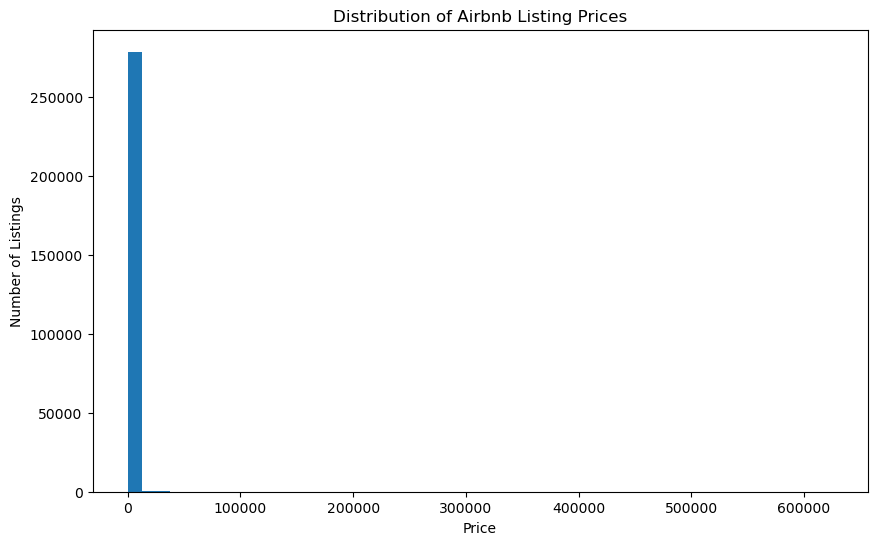

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(listings_eda["price"], bins=50)

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.show()

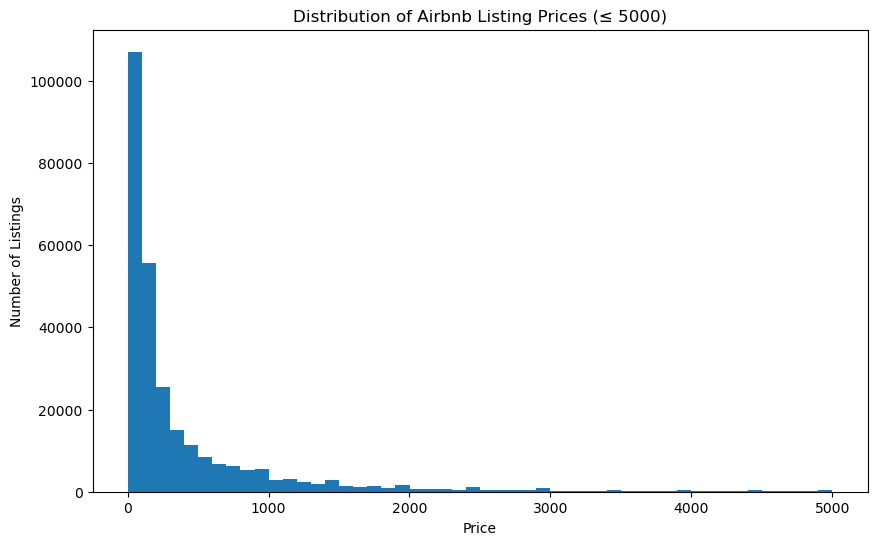

In [21]:
price_under_5000 = listings_eda[listings_eda["price"] <= 5000]

plt.figure(figsize=(10, 6))

plt.hist(price_under_5000["price"], bins=50)

plt.title("Distribution of Airbnb Listing Prices (≤ 5000)")
plt.xlabel("Price")
plt.ylabel("Number of Listings")

plt.show()

## Observations

- Most Airbnb listings are concentrated in the lower price ranges, particularly below 150–200.
- The price distribution is positively (right) skewed, with a long tail of expensive listings.
- Premium listings priced above 5000 represent only a small proportion (approximately 1.35%) of the marketplace.

## Business Insight

The Airbnb marketplace is largely composed of affordable to moderately priced accommodations. A small number of luxury listings increase the average price, making the mean substantially higher than the median. Therefore, the median is a better measure of the typical listing price.

## Recommendation

Future pricing analyses should use the median in addition to the mean and consider visualizing the typical market separately from luxury listings to avoid misleading interpretations caused by extreme values.

Section 2: Factors Associated with Guest Satisfaction
Business Question 5
Do Superhosts receive higher guest ratings than regular hosts?

Objective:
Determine whether Superhost status is associated with better guest ratings.

In [22]:
listings_eda["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
False    229185
True      50249
NaN         165
Name: count, dtype: int64

In [23]:
listings_eda["host_is_superhost"].head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: host_is_superhost, dtype: object

In [24]:
listings_eda["host_is_superhost"].dtype

dtype('O')

In [25]:
listings_eda.groupby("host_is_superhost")["review_scores_rating"].mean()

host_is_superhost
False    92.261410
True     96.996437
Name: review_scores_rating, dtype: float64

In [26]:
listings_eda["host_is_superhost"].value_counts()

host_is_superhost
False    229185
True      50249
Name: count, dtype: int64

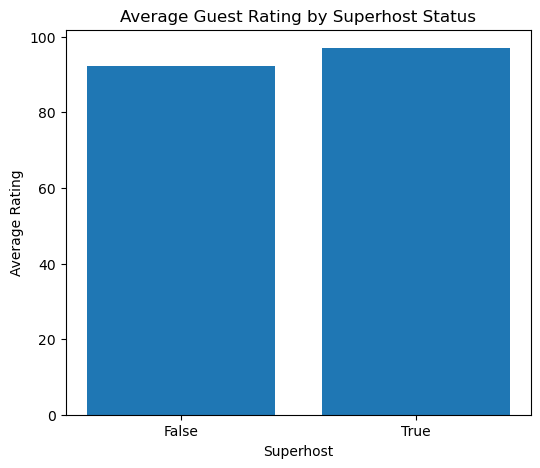

In [27]:
superhost_ratings = (
    listings_eda
    .groupby("host_is_superhost")["review_scores_rating"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))

plt.bar(
    superhost_ratings["host_is_superhost"].astype(str),
    superhost_ratings["review_scores_rating"]
)

plt.title("Average Guest Rating by Superhost Status")
plt.xlabel("Superhost")
plt.ylabel("Average Rating")

plt.show()

## Observations

- Superhosts have a higher average guest rating than regular hosts.
- The average rating for Superhosts is approximately 97, compared with approximately 92 for regular hosts.
- The difference is around 4.7 rating points.

## Business Insight

Superhost status is associated with higher guest ratings. While this analysis does not prove that becoming a Superhost causes higher ratings, it suggests that the practices required to earn Superhost status are linked to better guest experiences.

## Recommendation

Hosts should aim to meet the standards associated with Superhost status, such as maintaining responsiveness, reliability, and service quality. Further analyses should investigate which specific factors contribute most to achieving higher ratings.

Business Question 6
Does host response time influence guest ratings?

Objective:
Analyze whether faster host responses are associated with higher guest satisfaction.

In [28]:
listings_eda["host_response_time"].value_counts(dropna=False)

host_response_time
NaN                   128701
within an hour         83434
within a few hours     28891
within a day           23423
a few days or more     15150
Name: count, dtype: int64

In [29]:
response_rating = (
    listings_eda
    .groupby("host_response_time")["review_scores_rating"]
    .mean()
    .reset_index()
)

response_rating

,host_response_time,review_scores_rating
0,a few days or more,90.424429
1,within a day,93.513520
2,within a few hours,93.906879
3,within an hour,93.804804


In [30]:
order = [
    "within an hour",
    "within a few hours",
    "within a day",
    "a few days or more"
]

response_rating["host_response_time"] = pd.Categorical(
    response_rating["host_response_time"],
    categories=order,
    ordered=True
)

response_rating = response_rating.sort_values("host_response_time")

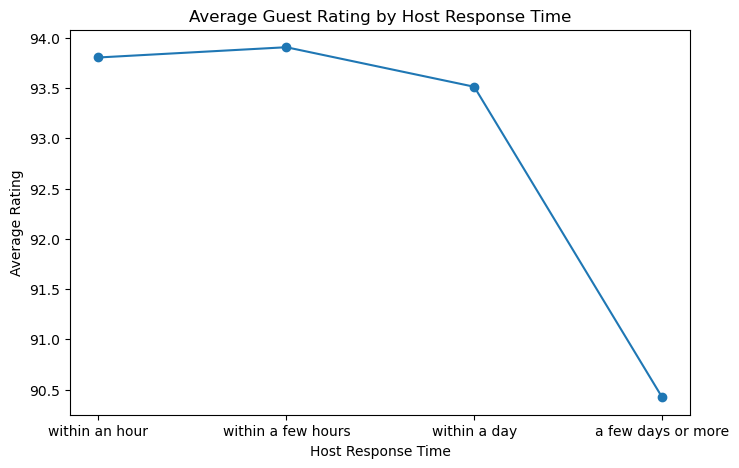

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    response_rating["host_response_time"],
    response_rating["review_scores_rating"],
    marker="o"
)

plt.title("Average Guest Rating by Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("Average Rating")

plt.show()

Business Question 7
Does the price of a listing influence guest ratings?

Objective:
Investigate whether higher-priced listings tend to receive better guest ratings.

In [32]:
bins = [0, 50, 100, 200, 500, 1000, 5000, float("inf")]

labels = [
    "0-50",
    "51-100",
    "101-200",
    "201-500",
    "501-1000",
    "1001-5000",
    "5000+"
]

listings_eda["price_range"] = pd.cut(
    listings_eda["price"],
    bins=bins,
    labels=labels
)

In [33]:
price_rating = (
    listings_eda
    .groupby("price_range")["review_scores_rating"]
    .mean()
    .reset_index()
)

price_rating

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_18908\3230048565.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("price_range")["review_scores_rating"]


,price_range,review_scores_rating
0,0-50,92.099456
1,51-100,93.273627
2,101-200,93.534085
3,201-500,93.526230
4,501-1000,93.840383
5,1001-5000,94.463825
6,5000+,95.117002


In [34]:
price_counts = (
    listings_eda["price_range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_counts.columns = ["Price Range", "Number of Listings"]

price_counts

,Price Range,Number of Listings
0,0-50,33074
1,51-100,73969
2,101-200,55650
3,201-500,51897
4,501-1000,32214
5,1001-5000,29017
6,5000+,3778


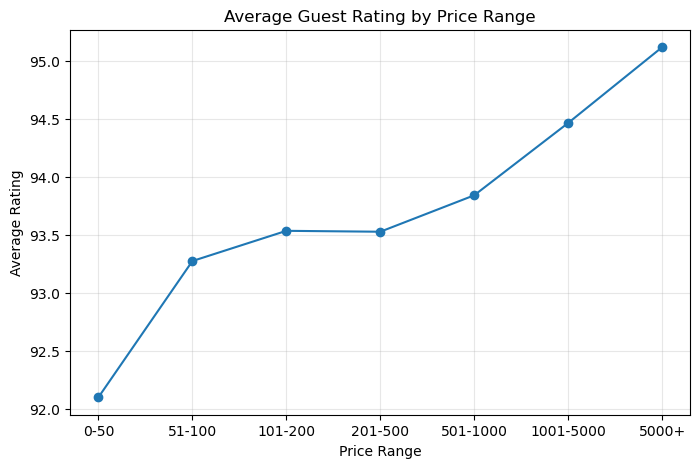

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    price_rating["price_range"].astype(str),
    price_rating["review_scores_rating"],
    marker="o"
)

plt.title("Average Guest Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

## Observations

- Average guest ratings generally increase as listing prices increase.
- Budget listings (0–50) have the lowest average rating (92.10).
- Premium listings (5000+) have the highest average rating (95.12).
- The increase in ratings is gradual rather than dramatic, with only about a 3-point difference between the lowest and highest price ranges.

## Business Insight

Higher-priced listings tend to receive slightly better guest ratings. However, this relationship does not necessarily mean that charging a higher price leads to better ratings. Premium listings may also offer better amenities, locations, cleanliness, or overall guest experiences, which could contribute to their higher ratings.

## Recommendation

Hosts should not assume that increasing prices alone will improve guest ratings. Instead, they should focus on improving the quality of the guest experience while pricing their listings competitively.

## Business Question 8: Do listings with more amenities receive higher guest ratings?

### Objective

Analyze whether listings offering more amenities tend to receive higher guest ratings.

**Business Relevance:**

Amenities are one of the few factors that hosts can directly improve. Understanding their relationship with guest satisfaction can help hosts prioritize investments that enhance the guest experience.

In [36]:
listings_eda["amenity_count"] = (
    listings_eda["amenities"]
    .str.count(",") + 1
)

listings_eda["amenity_count"].describe()

bins = [0,5,10,20,30,50,100]

labels = [
    "1-5",
    "6-10",
    "11-20",
    "21-30",
    "31-50",
    "50+"
]

listings_eda["amenity_group"] = pd.cut(
    listings_eda["amenity_count"],
    bins=bins,
    labels=labels
)

In [37]:
amenity_rating = (
    listings_eda
    .groupby("amenity_group")["review_scores_rating"]
    .mean()
    .reset_index()
)

amenity_rating

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_18908\2562971975.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("amenity_group")["review_scores_rating"]


,amenity_group,review_scores_rating
0,1-5,88.259126
1,6-10,90.782791
2,11-20,92.480309
3,21-30,94.276069
4,31-50,95.534808
5,50+,96.272834


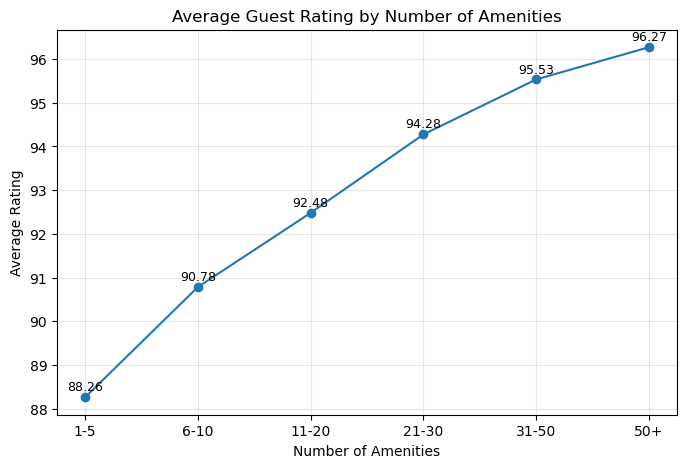

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    amenity_rating["amenity_group"].astype(str),
    amenity_rating["review_scores_rating"],
    marker="o"
)

for x, y in zip(
    amenity_rating["amenity_group"].astype(str),
    amenity_rating["review_scores_rating"]
):
    plt.text(x, y + 0.15, f"{y:.2f}", ha="center", fontsize=9)

plt.title("Average Guest Rating by Number of Amenities")
plt.xlabel("Number of Amenities")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

## Business Question 9: What characteristics do the highest-rated Airbnb listings have in common?

### Objective

Identify the common characteristics of highly rated Airbnb listings.

**Business Relevance:**

Understanding the features shared by top-rated listings helps identify best practices for hosts and provides evidence-based recommendations to improve guest satisfaction.

In [39]:
listings_eda["top_rated"] = listings_eda["review_scores_rating"] >= 95
listings_eda["top_rated"].value_counts()

top_rated
False    164334
True     115265
Name: count, dtype: int64

In [40]:
comparison = (
    listings_eda
    .groupby("top_rated")[[
        "price",
        "amenity_count",
        "bedrooms",
        "accommodates",
        "host_response_rate"
    ]]
    .mean()
    .round(2)
)

comparison

,price,amenity_count,bedrooms,accommodates,host_response_rate
top_rated,,,,,
False,667.40,17.45,1.52,3.25,0.83
True,525.83,22.58,1.51,3.34,0.91


In [41]:
superhost_pct = (
    pd.crosstab(
        listings_eda["top_rated"],
        listings_eda["host_is_superhost"],
        normalize="index"
    ) * 100
).round(2)

superhost_pct

host_is_superhost,False,True
top_rated,,
False,93.03,6.97
True,66.32,33.68


In [42]:
instant_pct = (
    pd.crosstab(
        listings_eda["top_rated"],
        listings_eda["instant_bookable"],
        normalize="index"
    ) * 100
).round(2)

instant_pct

instant_bookable,False,True
top_rated,,
False,55.57,44.43
True,63.04,36.96


In [43]:
summary = comparison.copy()

summary["Superhost %"] = superhost_pct[True]
summary["Instant Bookable %"] = instant_pct[True]

summary

,price,amenity_count,bedrooms,accommodates,host_response_rate,Superhost %,Instant Bookable %
top_rated,,,,,,,
False,667.40,17.45,1.52,3.25,0.83,6.97,44.43
True,525.83,22.58,1.51,3.34,0.91,33.68,36.96


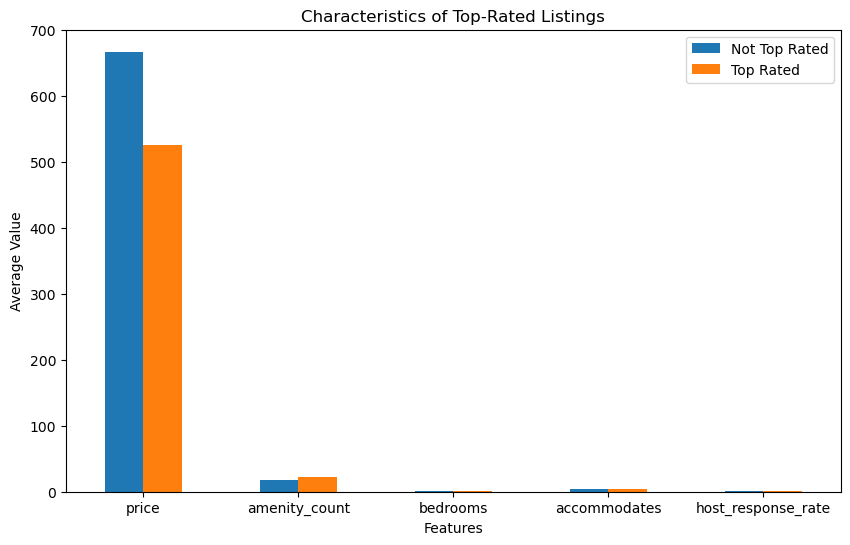

In [44]:
comparison.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Characteristics of Top-Rated Listings")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(["Not Top Rated","Top Rated"])

plt.show()

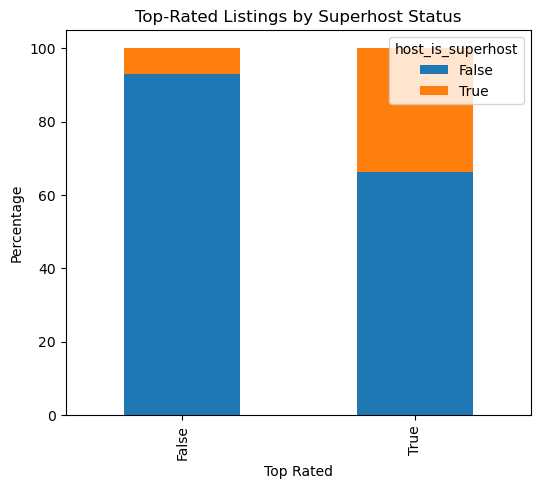

In [45]:
superhost_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Top-Rated Listings by Superhost Status")
plt.xlabel("Top Rated")
plt.ylabel("Percentage")

plt.show()

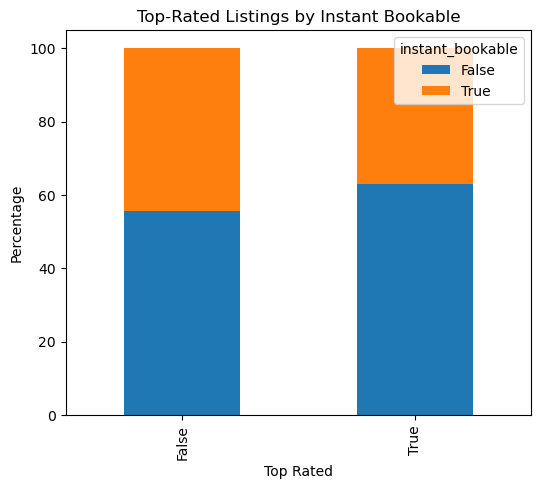

In [46]:
instant_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Top-Rated Listings by Instant Bookable")
plt.xlabel("Top Rated")
plt.ylabel("Percentage")

plt.show()

## Observations

- Top-rated listings have a higher average price than non-top-rated listings.
- Top-rated listings offer more amenities on average.
- Top-rated listings have higher host response rates.
- A larger proportion of top-rated listings are managed by Superhosts.
- Top-rated listings generally accommodate more guests and have slightly more bedrooms.

## Business Insight

Highly rated listings are not defined by a single characteristic. Instead, they combine several positive attributes, including better host responsiveness, richer amenities, competitive pricing, and strong host performance. This suggests that delivering an excellent guest experience requires a combination of service quality and well-equipped accommodations rather than focusing on a single factor.

## Recommendation

Hosts should adopt a holistic approach to improving their listings by enhancing amenities, maintaining prompt communication, striving for Superhost status, and continuously improving the overall guest experience. These combined improvements are more likely to contribute to consistently high guest ratings.

In [47]:
listings_eda.to_csv("../data/processed/Listings_EDA.csv", index=False)